<a href="https://colab.research.google.com/github/Amarissmona/ML-DL-Tasks/blob/main/CNN1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt



In [ ]:
# =====================================================
# Cell 2: Load the MNIST Image Dataset
# =====================================================

# Load handwritten digit dataset
# train_images and train_labels → training data
# test_images and test_labels → testing data

(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

# Print dataset shapes
print("Training data shape:", train_images.shape)
print("Testing data shape:", test_images.shape)

Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


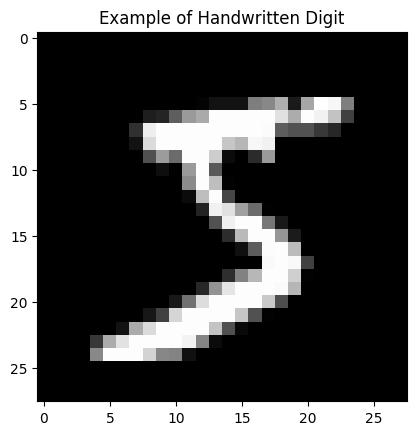

Label of this image: 5


In [ ]:
# =====================================================
# Cell 3: Display a Sample Image
# =====================================================

# Show the first image from the training dataset
plt.imshow(train_images[0], cmap='gray')

# Title of the image
plt.title("Example of Handwritten Digit")

# Display the image
plt.show()

# Print its corresponding label
print("Label of this image:", train_labels[0])

In [ ]:
train_images = train_images / 255.0,
test_images = test_images / 255.0

In [ ]:
# =====================================================
# Cell 5: Reshape Data for CNN Input
# =====================================================

# CNN expects 4D input:
# (number_of_images, height, width, channels)

# MNIST images are grayscale → 1 channel

train_images = train_images.reshape((60000, 28, 28, 1))
test_images = test_images.reshape((10000, 28, 28, 1))

In [ ]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])



In [ ]:
# =====================================================
# Cell 9: Train the CNN Model
# =====================================================

# Fit the model using training data
# epochs=5 means the model will learn from the dataset 5 times

history = model.fit(
    train_images,
    train_labels,
    epochs=5,
    validation_data=(test_images, test_labels)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 34ms/step - accuracy: 0.9562 - loss: 0.1426 - val_accuracy: 0.9844 - val_loss: 0.0465
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 78s 32ms/step - accuracy: 0.9861 - loss: 0.0456 - val_accuracy: 0.9879 - val_loss: 0.0373
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 33ms/step - accuracy: 0.9894 - loss: 0.0336 - val_accuracy: 0.9873 - val_loss: 0.0411
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 32ms/step - accuracy: 0.9929 - loss: 0.0234 - val_accuracy: 0.9897 - val_loss: 0.0301
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 33ms/step - accuracy: 0.9939 - loss: 0.0201 - val_accuracy: 0.9890 - val_loss: 0.0362


In [ ]:
# =====================================================
# Cell 10: Evaluate Model Performance
# =====================================================

# Evaluate the trained model on test dataset
test_loss, test_acc = model.evaluate(test_images, test_labels)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9890 - loss: 0.0362
Test Accuracy: 0.9890000224113464


In [ ]:
# =====================================================
# Cell 11: Make Predictions
# =====================================================

import numpy as np

# Predict probabilities for test images
predictions = model.predict(test_images)

# Get predicted digit for first test image
predicted_digit = np.argmax(predictions[0])

print("Predicted Digit:", predicted_digit)
print("Actual Digit:", test_labels[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Predicted Digit: 7
Actual Digit: 7
